In [ ]:
!pip install raster laspy[laszip] lazrs

In [ ]:
# I have to make sure laspy and laszip is installed
!pip install --force-reinstall laspy[laszip]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import laspy
import os
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# Mount and connect to the Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
def read_and_visualize_laz(file_path: str) -> None:
    """
    Reads a LiDAR .laz file and visualizes it as a 3D scatter plot.

    Parameters
    ----------
    file_path : str
        The path to the .laz file.

    Returns
    -------
    None
        Displays a 3D scatter plot of the LiDAR data.

    Raises
    ------
    FileNotFoundError
        If the file does not exist.
    ValueError
        If the file format is incorrect.
    Exception
        Any other unexpected error.
    """
    try:
        # Open the .laz file
        with laspy.open(file_path) as las_file:
            las = las_file.read()

        # Extract X, Y, Z coordinates
        x = las.x
        y = las.y
        z = las.z

        # Downsampling for better performance (adjust as needed)
        downsample_rate = max(1, len(x) // 100000)  # Show only every n-th point
        x, y, z = x[::downsample_rate], y[::downsample_rate], z[::downsample_rate]

        # Create a 3D scatter plot
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(x, y, z, c=z, cmap='terrain', s=0.5, alpha=0.5)

        # Labels and title
        ax.set_xlabel("X Coordinate")
        ax.set_ylabel("Y Coordinate")
        ax.set_zlabel("Height (Z)")
        ax.set_title("LiDAR point cloud data")
        fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label="Height")

        plt.show()

    except FileNotFoundError:
        raise FileNotFoundError(f"File not found: {file_path}")
    except ValueError:
        raise ValueError("Invalid file format. Please provide a valid .laz file.")
    except Exception as e:
        raise Exception(f"An error occurred: {e}")

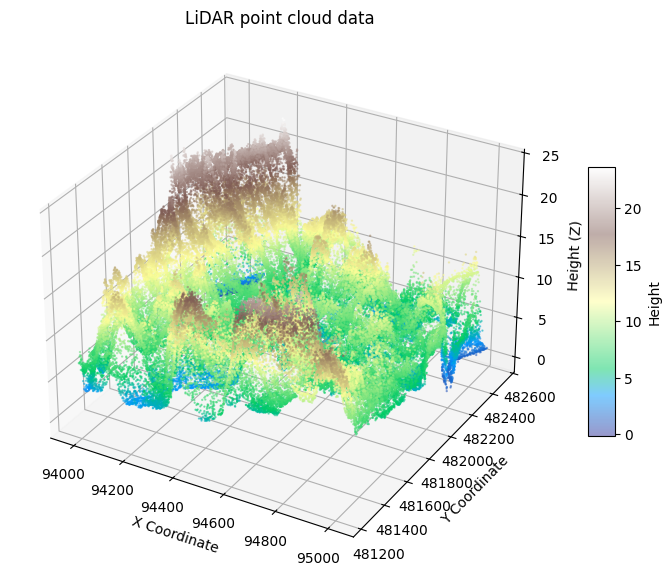

In [ ]:
# Just an example that read and visualize the LiDAR *.laz file.

# The directory of *.laz file
laz_file_path = "/content/drive/MyDrive/Colab_Notebooks/AWD/datasets/24HN1_25/1_original/24HN1_25.laz"

# Run the read and visualize.
read_and_visualize_laz(laz_file_path)